In [1]:
import matplotlib.pyplot as plt

## Pre generate arrivals and LOS

In [2]:
import numpy as np

def generate_arrivals_cont(max_time=365, exponential=False):
    """
    Pre-generates all arrivals and lengths of stay (LOS) for a single year.
    Returns a list of sorted tuples: (arrival_time, patient_type, length_of_stay)
    """
    arrivals = []
    
    # Ward A (Regular): lambda_1(t) = -(1/3650)t^2 + (1/10)t
    t = 0
    max_lambda_A = 9.125 
    while True:
        t -= (1 / max_lambda_A) * np.log(np.random.rand())
        if t > max_time: break
        lambda_t = -(1/3650) * t**2 + 0.1 * t
        if np.random.rand() <= (lambda_t / max_lambda_A):
            sigma = np.sqrt(np.log(2))
            if exponential:
                los = np.random.exponential(scale=8)
            else:
                los = np.random.lognormal(mean=np.log(4*np.sqrt(2)), sigma=sigma)
            arrivals.append((t, 'A', los))

    # Ward B (Intensive): lambda_2(t) = 0.2 * lambda_1(t)
    t = 0
    max_lambda_B = 1.825 
    while True:
        t -= (1 / max_lambda_B) * np.log(np.random.rand())
        if t > max_time: break
        lambda_t = 0.2 * (-(1/3650) * t**2 + 0.1 * t)
        if np.random.rand() <= (lambda_t / max_lambda_B):
            sigma = np.sqrt(np.log(2))
            if exponential:
                los = np.random.exponential(scale=12)
            else:
                los = np.random.lognormal(mean=np.log(6*np.sqrt(2)), sigma=sigma)
            arrivals.append((t, 'B', los))

    # Ward C (Other): Homogeneous Poisson Process, lambda_3 = 6
    t = 0
    lambda_C = 6
    while True:
        t -= (1 / lambda_C) * np.log(np.random.rand())
        if t > max_time: break
        sigma = np.sqrt(np.log(2))
        if exponential:
            los = np.random.exponential(scale=10)
        else:
            los = np.random.lognormal(mean=np.log(5*np.sqrt(2)), sigma=sigma)
        arrivals.append((t, 'C', los))

    # Sort all arrivals chronologically
    arrivals.sort(key=lambda x: x[0])
    return arrivals

n_replications = 10
replications_data_cont_lognormal = []
replications_data_cont_exponential = []

for i in range(n_replications):
    # Set a unique seed per replication to make them reproducible
    np.random.seed(42 + i)
    replications_data_cont_lognormal.append(generate_arrivals_cont(max_time=365))
    replications_data_cont_exponential.append(generate_arrivals_cont(max_time=365, exponential=True))

print(f"Pre-generated arrivals and stays for {n_replications} replications.")

Pre-generated arrivals and stays for 10 replications.


In [3]:
import numpy as np

def generate_arrivals_discrete(max_time=365, exponential=False):
    """
    Generates arrivals day-by-day using Poisson distributions.
    Returns a list of sorted tuples: (arrival_time, patient_type, length_of_stay)
    """
    arrivals = []
    sigma = np.sqrt(np.log(2))
    
    for d in range(max_time+1):
        # We evaluate the rate at the midpoint of the day (d + 0.5)
        t_mid = d + 0.5
        
        # --- 1. Ward A (Regular) ---
        lambda_A = max(0, -(1/3650) * (t_mid**2) + 0.1 * t_mid)
        # Sample the number of arrivals for this day
        n_A = np.random.poisson(lambda_A)
        
        for _ in range(n_A):
            arrival_time = d + np.random.rand()
            if exponential:
                los = np.random.exponential(scale=8)
            else:
                los = np.random.lognormal(mean=np.log(4*np.sqrt(2)), sigma=sigma)
            arrivals.append((arrival_time, 'A', los))
            
        # --- 2. Ward B (Intensive) ---
        lambda_B = 0.2 * lambda_A
        n_B = np.random.poisson(lambda_B)
        for _ in range(n_B):
            arrival_time = d + np.random.rand()
            if exponential:
                los = np.random.exponential(scale=12)
            else:
                los = np.random.lognormal(mean=np.log(6*np.sqrt(2)), sigma=sigma)
            arrivals.append((arrival_time, 'B', los))
            
        # --- 3. Ward C (Other) ---
        lambda_C = 6.0
        n_C = np.random.poisson(lambda_C)
        for _ in range(n_C):
            arrival_time = d + np.random.rand()
            if exponential:
                los = np.random.exponential(scale=10)
            else:
                los = np.random.lognormal(mean=np.log(5*np.sqrt(2)), sigma=sigma)
            arrivals.append((arrival_time, 'C', los))
            
    arrivals.sort(key=lambda x: x[0])
    return arrivals



n_replications = 10
replications_data_disc_lognormal = []
replications_data_disc_exponential = []

for i in range(n_replications):
    np.random.seed(42 + i)
    replications_data_disc_lognormal.append(generate_arrivals_discrete(max_time=365))
    replications_data_disc_exponential.append(generate_arrivals_discrete(max_time=365, exponential=True))

print(f"Pre-generated arrivals and stays for {n_replications} replications.")

Pre-generated arrivals and stays for 10 replications.


## Main hospital simulation

In [5]:
def simulate_hospital(cap_A, cap_B, cap_C, arrivals, max_time=365):
    beds_A = []
    beds_B = []
    beds_C = []
    
    arrivals_count = {'A': 0, 'B': 0, 'C': 0}
    relocated = {'A': 0, 'B': 0, 'C': 0}
    util_integral = {'A': 0.0, 'B': 0.0, 'C': 0.0}
    
    for t, p_type, los in arrivals:
        beds_A = [dep for dep in beds_A if dep > t]
        beds_B = [dep for dep in beds_B if dep > t]
        beds_C = [dep for dep in beds_C if dep > t]
        
        arrivals_count[p_type] += 1
        departure_time = t + los
        
        if p_type == 'C':
            if len(beds_C) < cap_C:
                beds_C.append(departure_time)
                util_integral['C'] += los
            else:
                relocated['C'] += 1
                
        elif p_type == 'B':
            if len(beds_B) < cap_B:
                beds_B.append(departure_time)
                util_integral['B'] += los
            elif len(beds_A) < cap_A: # Overflow to Ward A
                beds_A.append(departure_time)
                util_integral['A'] += los
            else:
                relocated['B'] += 1
                
        elif p_type == 'A':
            if len(beds_A) < cap_A:
                beds_A.append(departure_time)
                util_integral['A'] += los
            else:
                relocated['A'] += 1
                
    blocking_prob = {
        k: (relocated[k] / arrivals_count[k] if arrivals_count[k] > 0 else 0) 
        for k in ['A', 'B', 'C']
    }
    
    avg_utilization = {
        'A': util_integral['A'] / (cap_A * max_time) if cap_A > 0 else 0,
        'B': util_integral['B'] / (cap_B * max_time) if cap_B > 0 else 0,
        'C': util_integral['C'] / (cap_C * max_time) if cap_C > 0 else 0
    }
    
    total_relocated = sum(relocated.values())
    total_arrivals = sum(arrivals_count.values())
    total_blocking_prob = total_relocated / total_arrivals if total_arrivals > 0 else 0

    return {
        "arrivals": arrivals_count,
        "relocated": relocated,
        "blocking_probabilities": blocking_prob,
        "total_blocking_probability": total_blocking_prob,
        "total_relocated": total_relocated,
        "avg_utilization": avg_utilization
    }

## Optimal bed distributions for various number of beds

In [ ]:
# 75 lognormal

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 1

total_beds = 75
min_beds = 0

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 10 replications per combination.



Grid Search Progress:   0%|          | 0/76 [00:00<?, ?it/s]

{'Beds': (32, 0, 43),
 'arrivals': {'A': 2212.8, 'B': 435.5, 'C': 2193.5},
 'relocated': {'A': 1216.0, 'B': 239.0, 'C': 650.5},
 'blocking_probabilities': {'A': 0.5493127087404968,
  'B': 0.5486445811297812,
  'C': 0.296413858259898},
 'total_blocking_probability': 0.43481560996009183,
 'total_relocated': 2105.5,
 'avg_utilization': {'A': 0.8802318009990209,
  'B': 0.0,
  'C': 0.9681004321293768}}

In [ ]:
# 75 exponential

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = True
INTENSIVE_WEIGHT = 1

total_beds = 75
min_beds = 0

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 10 replications per combination.



Grid Search Progress:   0%|          | 0/76 [00:00<?, ?it/s]

{'Beds': (34, 0, 41),
 'arrivals': {'A': 2230.3, 'B': 443.3, 'C': 2216.5},
 'relocated': {'A': 1173.4, 'B': 231.7, 'C': 771.7},
 'blocking_probabilities': {'A': 0.526057831563093,
  'B': 0.5226077519395125,
  'C': 0.34803048357246025},
 'total_blocking_probability': 0.44509794982861833,
 'total_relocated': 2176.8,
 'avg_utilization': {'A': 0.8790304435249237,
  'B': 0.0,
  'C': 0.9772955787317515}}

In [ ]:
# 50 lognormal

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 1

total_beds = 50
min_beds = 0

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 50 beds...
Running 10 replications per combination.



Grid Search Progress:   0%|          | 0/51 [00:00<?, ?it/s]

{'Beds': (25, 0, 25),
 'arrivals': {'A': 2212.8, 'B': 435.5, 'C': 2193.5},
 'relocated': {'A': 1414.9, 'B': 276.4, 'C': 1272.3},
 'blocking_probabilities': {'A': 0.639204308535802,
  'B': 0.6343833290966019,
  'C': 0.5800031116327492},
 'total_blocking_probability': 0.612048568009947,
 'total_relocated': 2963.6,
 'avg_utilization': {'A': 0.9014794634153642,
  'B': 0.0,
  'C': 0.9938567051468272}}

In [ ]:
# 100 lognormal

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 1

total_beds = 100
min_beds = 0

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 100 beds...
Running 10 replications per combination.



Grid Search Progress:   0%|          | 0/101 [00:00<?, ?it/s]

{'Beds': (48, 0, 52),
 'arrivals': {'A': 2212.8, 'B': 435.5, 'C': 2193.5},
 'relocated': {'A': 803.0, 'B': 159.8, 'C': 386.9},
 'blocking_probabilities': {'A': 0.3627573066156609,
  'B': 0.3668151699821015,
  'C': 0.17624758567856721},
 'total_blocking_probability': 0.27872376969647145,
 'total_relocated': 1349.7,
 'avg_utilization': {'A': 0.8297280624370362,
  'B': 0.0,
  'C': 0.9465053172896571}}

## Continous

In [ ]:
# 75 lognormal + continous

from tqdm.notebook import tqdm

CONTINUOUS = True
EXPONENTIAL = False
INTENSIVE_WEIGHT = 1

total_beds = 75
min_beds = 0

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 10 replications per combination.



Grid Search Progress:   0%|          | 0/76 [00:00<?, ?it/s]

{'Beds': (32, 1, 42),
 'arrivals': {'A': 2215.1, 'B': 443.5, 'C': 2169.4},
 'relocated': {'A': 1220.3, 'B': 231.8, 'C': 663.0},
 'blocking_probabilities': {'A': 0.5507906796704851,
  'B': 0.5224010391672668,
  'C': 0.30555241766174807},
 'total_blocking_probability': 0.4380508191045755,
 'total_relocated': 2115.1,
 'avg_utilization': {'A': 0.8822845681417151,
  'B': 0.9017885129051738,
  'C': 0.9693669126783021}}

## Experiments

In [6]:
# 75 lognormal, intensive care weight 2

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 2

total_beds = 75
min_beds = 0

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 10 replications per combination.



Grid Search Progress:   0%|          | 0/76 [00:00<?, ?it/s]

{'Beds': (35, 8, 32),
 'arrivals': {'A': 2212.8, 'B': 435.5, 'C': 2193.5},
 'relocated': {'A': 1025.2, 'B': 129.3, 'C': 1020.1},
 'blocking_probabilities': {'A': 0.4630669266462806,
  'B': 0.2964669736334219,
  'C': 0.46497370428432294},
 'total_blocking_probability': 0.4490837379762647,
 'total_relocated': 2174.6,
 'avg_utilization': {'A': 0.8451724306270607,
  'B': 0.8063133404952294,
  'C': 0.9863705696996664}}

In [7]:
# 75 lognormal, 10 min beds

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 1

total_beds = 75
min_beds = 10

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 10 replications per combination.



Grid Search Progress:   0%|          | 0/46 [00:00<?, ?it/s]

{'Beds': (32, 10, 33),
 'arrivals': {'A': 2212.8, 'B': 435.5, 'C': 2193.5},
 'relocated': {'A': 1089.3, 'B': 115.6, 'C': 985.3},
 'blocking_probabilities': {'A': 0.4920596202635485,
  'B': 0.265136923763153,
  'C': 0.44908952694712373},
 'total_blocking_probability': 0.4523036049000201,
 'total_relocated': 2190.2,
 'avg_utilization': {'A': 0.8523344382393011,
  'B': 0.7820284734806604,
  'C': 0.9847326752329264}}

## plots

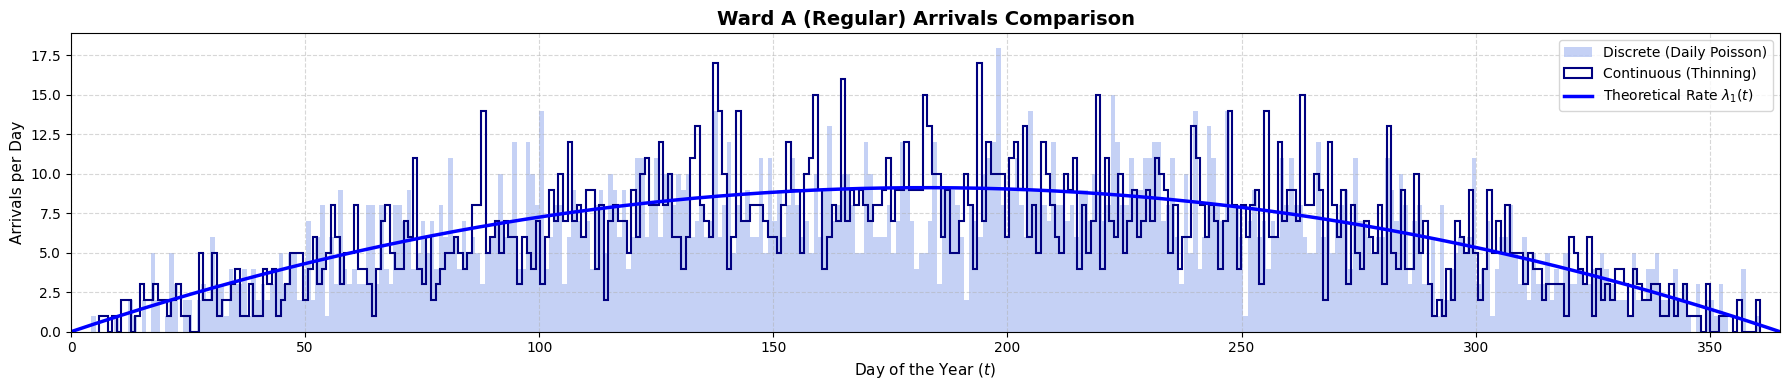

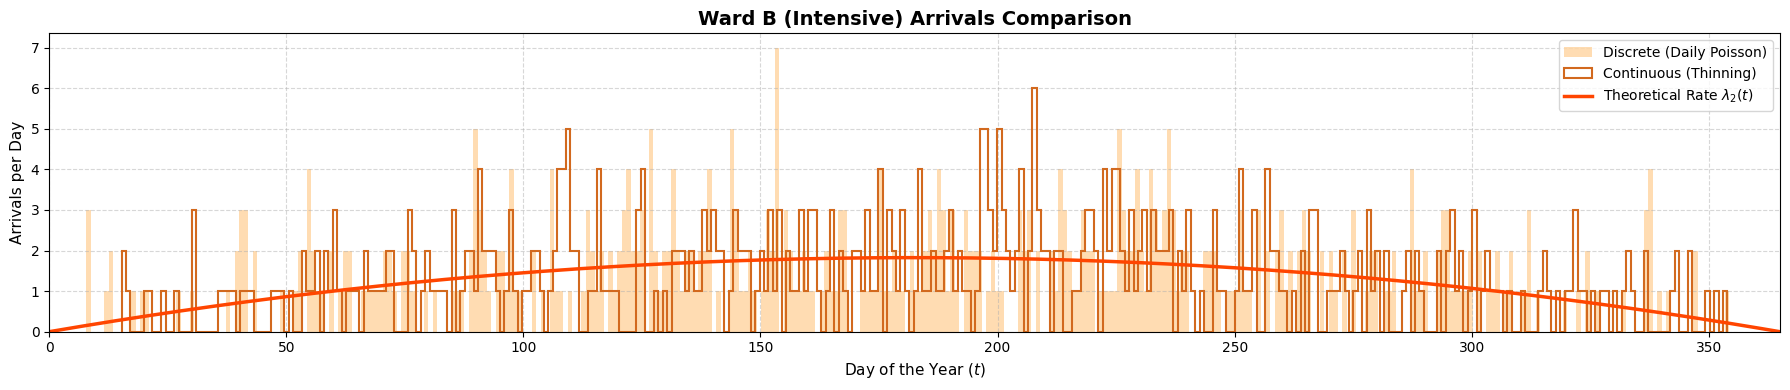

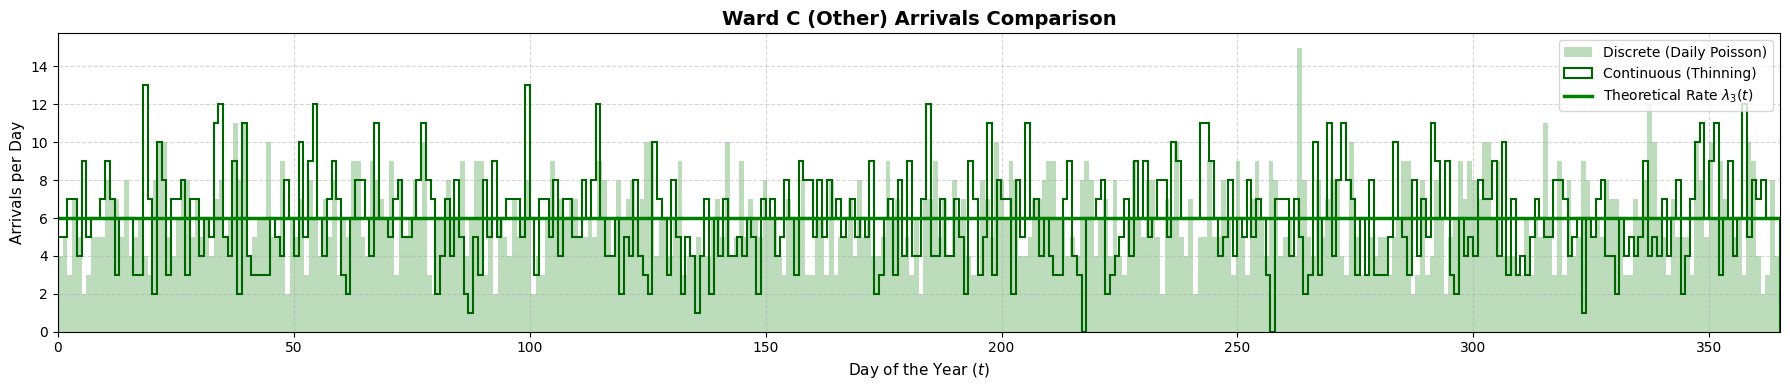

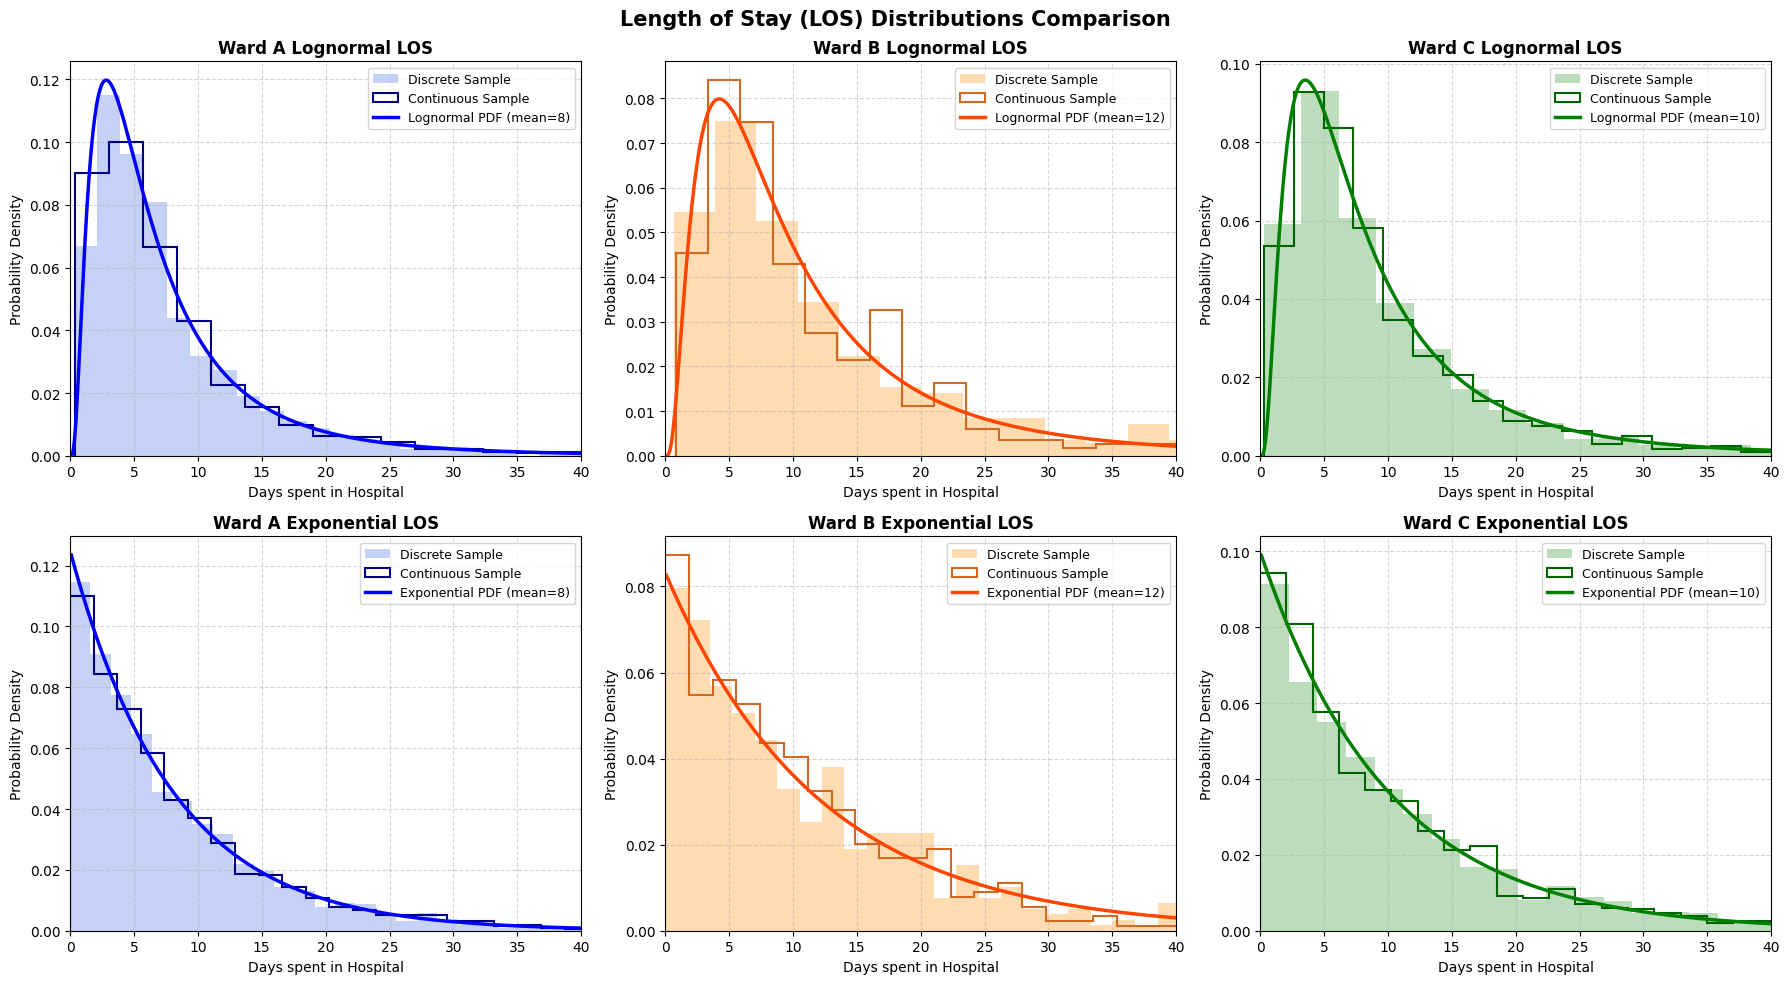

--- TOTAL ARRIVALS FOR THE YEAR (Replication 0) ---
Continuous Lognormal: Ward A = 2171 | Ward B = 461 | Ward C = 2159 | Total = 4791
Discrete Lognormal:   Ward A = 2201 | Ward B = 442 | Ward C = 2194 | Total = 4837


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


arrivals_cont_log = replications_data_cont_lognormal[0]
arrivals_cont_exp = replications_data_cont_exponential[0]
arrivals_disc_log = replications_data_disc_lognormal[0]
arrivals_disc_exp = replications_data_disc_exponential[0]


times_cont_A = [t for t, p_type, los in arrivals_cont_log if p_type == 'A']
times_cont_B = [t for t, p_type, los in arrivals_cont_log if p_type == 'B']
times_cont_C = [t for t, p_type, los in arrivals_cont_log if p_type == 'C']


times_disc_A = [t for t, p_type, los in arrivals_disc_log if p_type == 'A']
times_disc_B = [t for t, p_type, los in arrivals_disc_log if p_type == 'B']
times_disc_C = [t for t, p_type, los in arrivals_disc_log if p_type == 'C']


los_cont_log_A = [los for t, p_type, los in arrivals_cont_log if p_type == 'A']
los_cont_log_B = [los for t, p_type, los in arrivals_cont_log if p_type == 'B']
los_cont_log_C = [los for t, p_type, los in arrivals_cont_log if p_type == 'C']

los_disc_log_A = [los for t, p_type, los in arrivals_disc_log if p_type == 'A']
los_disc_log_B = [los for t, p_type, los in arrivals_disc_log if p_type == 'B']
los_disc_log_C = [los for t, p_type, los in arrivals_disc_log if p_type == 'C']


los_cont_exp_A = [los for t, p_type, los in arrivals_cont_exp if p_type == 'A']
los_cont_exp_B = [los for t, p_type, los in arrivals_cont_exp if p_type == 'B']
los_cont_exp_C = [los for t, p_type, los in arrivals_cont_exp if p_type == 'C']

los_disc_exp_A = [los for t, p_type, los in arrivals_disc_exp if p_type == 'A']
los_disc_exp_B = [los for t, p_type, los in arrivals_disc_exp if p_type == 'B']
los_disc_exp_C = [los for t, p_type, los in arrivals_disc_exp if p_type == 'C']



t_grid = np.linspace(0, 365, 1000)
rate_A_theoretical = -(1/3650) * (t_grid**2) + 0.1 * t_grid
rate_B_theoretical = 0.2 * rate_A_theoretical
rate_C_theoretical = np.ones_like(t_grid) * 6.0

sigma = np.sqrt(np.log(2))
los_grid = np.linspace(0.1, 40, 500)



# --- Plot 1: Ward A Arrivals ---
plt.figure(figsize=(18, 4.0))
plt.hist(times_disc_A, bins=365, color='royalblue', alpha=0.3, label='Discrete (Daily Poisson)')
plt.hist(times_cont_A, bins=365, histtype='step', color='navy', linewidth=1.5, label='Continuous (Thinning)')
plt.plot(t_grid, rate_A_theoretical, color='blue', linewidth=2.5, label='Theoretical Rate $\lambda_1(t)$')
plt.title('Ward A (Regular) Arrivals Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Year ($t$)', fontsize=11)
plt.ylabel('Arrivals per Day', fontsize=11)
plt.xlim(0, 365)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

# --- Plot 2: Ward B Arrivals ---
plt.figure(figsize=(18, 4.0))
plt.hist(times_disc_B, bins=365, color='darkorange', alpha=0.3, label='Discrete (Daily Poisson)')
plt.hist(times_cont_B, bins=365, histtype='step', color='chocolate', linewidth=1.5, label='Continuous (Thinning)')
plt.plot(t_grid, rate_B_theoretical, color='orangered', linewidth=2.5, label='Theoretical Rate $\lambda_2(t)$')
plt.title('Ward B (Intensive) Arrivals Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Year ($t$)', fontsize=11)
plt.ylabel('Arrivals per Day', fontsize=11)
plt.xlim(0, 365)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

# --- Plot 3: Ward C Arrivals ---
plt.figure(figsize=(18, 4.0))
plt.hist(times_disc_C, bins=365, color='forestgreen', alpha=0.3, label='Discrete (Daily Poisson)')
plt.hist(times_cont_C, bins=365, histtype='step', color='darkgreen', linewidth=1.5, label='Continuous (Thinning)')
plt.plot(t_grid, rate_C_theoretical, color='green', linewidth=2.5, label='Theoretical Rate $\lambda_3(t)$')
plt.title('Ward C (Other) Arrivals Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Year ($t$)', fontsize=11)
plt.ylabel('Arrivals per Day', fontsize=11)
plt.xlim(0, 365)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.25)


# --- Subplot 1: Ward A Lognormal ---
pdf_log_A = stats.lognorm.pdf(los_grid, s=sigma, scale=4*np.sqrt(2))
axes[0, 0].hist(los_disc_log_A, bins=40, density=True, color='royalblue', alpha=0.3, label='Discrete Sample')
axes[0, 0].hist(los_cont_log_A, bins=40, density=True, histtype='step', color='navy', linewidth=1.5, label='Continuous Sample')
axes[0, 0].plot(los_grid, pdf_log_A, color='blue', linewidth=2.5, label='Lognormal PDF (mean=8)')
axes[0, 0].set_title('Ward A Lognormal LOS', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Days spent in Hospital', fontsize=10)
axes[0, 0].set_ylabel('Probability Density', fontsize=10)
axes[0, 0].set_xlim(0, 40)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)
axes[0, 0].legend(fontsize=9)

# --- Subplot 2: Ward B Lognormal ---
pdf_log_B = stats.lognorm.pdf(los_grid, s=sigma, scale=6*np.sqrt(2))
axes[0, 1].hist(los_disc_log_B, bins=40, density=True, color='darkorange', alpha=0.3, label='Discrete Sample')
axes[0, 1].hist(los_cont_log_B, bins=40, density=True, histtype='step', color='chocolate', linewidth=1.5, label='Continuous Sample')
axes[0, 1].plot(los_grid, pdf_log_B, color='orangered', linewidth=2.5, label='Lognormal PDF (mean=12)')
axes[0, 1].set_title('Ward B Lognormal LOS', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Days spent in Hospital', fontsize=10)
axes[0, 1].set_ylabel('Probability Density', fontsize=10)
axes[0, 1].set_xlim(0, 40)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)
axes[0, 1].legend(fontsize=9)

# --- Subplot 3: Ward C Lognormal ---
pdf_log_C = stats.lognorm.pdf(los_grid, s=sigma, scale=5*np.sqrt(2))
axes[0, 2].hist(los_disc_log_C, bins=40, density=True, color='forestgreen', alpha=0.3, label='Discrete Sample')
axes[0, 2].hist(los_cont_log_C, bins=40, density=True, histtype='step', color='darkgreen', linewidth=1.5, label='Continuous Sample')
axes[0, 2].plot(los_grid, pdf_log_C, color='green', linewidth=2.5, label='Lognormal PDF (mean=10)')
axes[0, 2].set_title('Ward C Lognormal LOS', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Days spent in Hospital', fontsize=10)
axes[0, 2].set_ylabel('Probability Density', fontsize=10)
axes[0, 2].set_xlim(0, 40)
axes[0, 2].grid(True, linestyle='--', alpha=0.5)
axes[0, 2].legend(fontsize=9)


# --- Subplot 4: Ward A Exponential ---
pdf_exp_A = stats.expon.pdf(los_grid, scale=8.0)
axes[1, 0].hist(los_disc_exp_A, bins=40, density=True, color='royalblue', alpha=0.3, label='Discrete Sample')
axes[1, 0].hist(los_cont_exp_A, bins=40, density=True, histtype='step', color='navy', linewidth=1.5, label='Continuous Sample')
axes[1, 0].plot(los_grid, pdf_exp_A, color='blue', linewidth=2.5, label='Exponential PDF (mean=8)')
axes[1, 0].set_title('Ward A Exponential LOS', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Days spent in Hospital', fontsize=10)
axes[1, 0].set_ylabel('Probability Density', fontsize=10)
axes[1, 0].set_xlim(0, 40)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].legend(fontsize=9)

# --- Subplot 5: Ward B Exponential ---
pdf_exp_B = stats.expon.pdf(los_grid, scale=12.0)
axes[1, 1].hist(los_disc_exp_B, bins=40, density=True, color='darkorange', alpha=0.3, label='Discrete Sample')
axes[1, 1].hist(los_cont_exp_B, bins=40, density=True, histtype='step', color='chocolate', linewidth=1.5, label='Continuous Sample')
axes[1, 1].plot(los_grid, pdf_exp_B, color='orangered', linewidth=2.5, label='Exponential PDF (mean=12)')
axes[1, 1].set_title('Ward B Exponential LOS', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Days spent in Hospital', fontsize=10)
axes[1, 1].set_ylabel('Probability Density', fontsize=10)
axes[1, 1].set_xlim(0, 40)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)
axes[1, 1].legend(fontsize=9)

# --- Subplot 6: Ward C Exponential ---
pdf_exp_C = stats.expon.pdf(los_grid, scale=10.0)
axes[1, 2].hist(los_disc_exp_C, bins=40, density=True, color='forestgreen', alpha=0.3, label='Discrete Sample')
axes[1, 2].hist(los_cont_exp_C, bins=40, density=True, histtype='step', color='darkgreen', linewidth=1.5, label='Continuous Sample')
axes[1, 2].plot(los_grid, pdf_exp_C, color='green', linewidth=2.5, label='Exponential PDF (mean=10)')
axes[1, 2].set_title('Ward C Exponential LOS', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Days spent in Hospital', fontsize=10)
axes[1, 2].set_ylabel('Probability Density', fontsize=10)
axes[1, 2].set_xlim(0, 40)
axes[1, 2].grid(True, linestyle='--', alpha=0.5)
axes[1, 2].legend(fontsize=9)

plt.suptitle('Length of Stay (LOS) Distributions Comparison', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 4. Print printouts comparing totals
print(f"--- TOTAL ARRIVALS FOR THE YEAR (Replication 0) ---")
print(f"Continuous Lognormal: Ward A = {len(times_cont_A):4d} | Ward B = {len(times_cont_B):3d} | Ward C = {len(times_cont_C):4d} | Total = {len(arrivals_cont_log):4d}")
print(f"Discrete Lognormal:   Ward A = {len(times_disc_A):4d} | Ward B = {len(times_disc_B):3d} | Ward C = {len(times_disc_C):4d} | Total = {len(arrivals_disc_log):4d}")

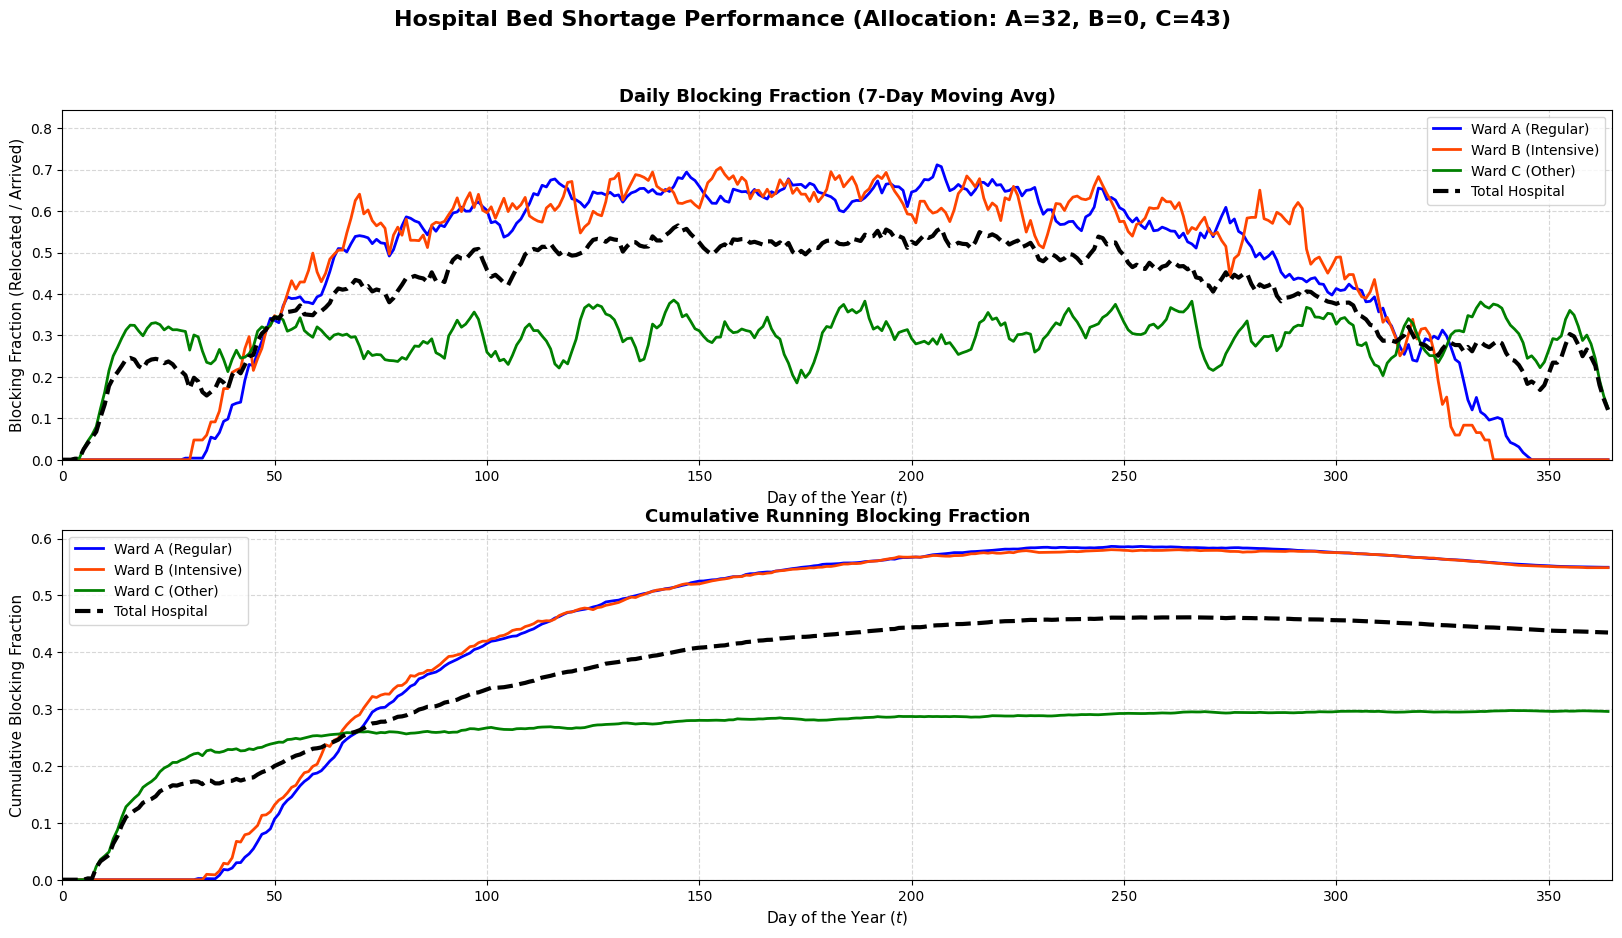

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_hospital_daily(cap_A, cap_B, cap_C, arrivals, max_time=365):
    """
    Runs the simulation and returns daily arrivals and relocations
    for each day of the year (0 to 365).
    """
    beds_A = []
    beds_B = []
    beds_C = []
    
    daily_arrivals = {'A': np.zeros(max_time), 'B': np.zeros(max_time), 'C': np.zeros(max_time)}
    daily_relocated = {'A': np.zeros(max_time), 'B': np.zeros(max_time), 'C': np.zeros(max_time)}
    
    for t, p_type, los in arrivals:
        day = int(t)
        if day < 0 or day >= max_time:
            continue
            
        beds_A = [dep for dep in beds_A if dep > t]
        beds_B = [dep for dep in beds_B if dep > t]
        beds_C = [dep for dep in beds_C if dep > t]
        
        daily_arrivals[p_type][day] += 1
        departure_time = t + los
        
        if p_type == 'C':
            if len(beds_C) < cap_C:
                beds_C.append(departure_time)
            else:
                daily_relocated['C'][day] += 1
                
        elif p_type == 'B':
            if len(beds_B) < cap_B:
                beds_B.append(departure_time)
            elif len(beds_A) < cap_A: # Intensive overflowing to Regular (A)
                beds_A.append(departure_time)
            else:
                daily_relocated['B'][day] += 1
                
        elif p_type == 'A':
            if len(beds_A) < cap_A:
                beds_A.append(departure_time)
            else:
                daily_relocated['A'][day] += 1
                
    return daily_arrivals, daily_relocated



cap_A = 32
cap_B = 0
cap_C = 43
max_time = 365

all_reps_arr = {'A': [], 'B': [], 'C': []}
all_reps_rel = {'A': [], 'B': [], 'C': []}

for rep_arrivals in replications_data:
    daily_arr, daily_rel = simulate_hospital_daily(cap_A, cap_B, cap_C, rep_arrivals, max_time)
    for k in ['A', 'B', 'C']:
        all_reps_arr[k].append(daily_arr[k])
        all_reps_rel[k].append(daily_rel[k])

mean_arr = {k: np.mean(all_reps_arr[k], axis=0) for k in ['A', 'B', 'C']}
mean_rel = {k: np.mean(all_reps_rel[k], axis=0) for k in ['A', 'B', 'C']}


days = np.arange(max_time)

daily_blocking = {}
for k in ['A', 'B', 'C']:
    daily_blocking[k] = np.zeros(max_time)
    valid_mask = mean_arr[k] > 0
    daily_blocking[k][valid_mask] = mean_rel[k][valid_mask] / mean_arr[k][valid_mask]

mean_total_arr = mean_arr['A'] + mean_arr['B'] + mean_arr['C']
mean_total_rel = mean_rel['A'] + mean_rel['B'] + mean_rel['C']
daily_blocking['Total'] = np.zeros(max_time)
valid_total = mean_total_arr > 0
daily_blocking['Total'][valid_total] = mean_total_rel[valid_total] / mean_total_arr[valid_total]

cum_arr = {k: np.cumsum(mean_arr[k]) for k in ['A', 'B', 'C']}
cum_rel = {k: np.cumsum(mean_rel[k]) for k in ['A', 'B', 'C']}

cum_blocking = {}
for k in ['A', 'B', 'C']:
    cum_blocking[k] = np.zeros(max_time)
    valid_mask = cum_arr[k] > 0
    cum_blocking[k][valid_mask] = cum_rel[k][valid_mask] / cum_arr[k][valid_mask]

cum_total_arr = np.cumsum(mean_total_arr)
cum_total_rel = np.cumsum(mean_total_rel)
cum_blocking['Total'] = np.zeros(max_time)
valid_total = cum_total_arr > 0
cum_blocking['Total'][valid_total] = cum_total_rel[valid_total] / cum_total_arr[valid_total]


fig, axes = plt.subplots(2, 1, figsize=(20, 10))
plt.subplots_adjust(wspace=0.22)

# Helper for daily smoothing
def moving_average(y, window=7):
    return np.convolve(y, np.ones(window)/window, mode='same')


axes[0].plot(days, moving_average(daily_blocking['A']), color='blue', linewidth=2, label='Ward A (Regular)')
axes[0].plot(days, moving_average(daily_blocking['B']), color='orangered', linewidth=2, label='Ward B (Intensive)')
axes[0].plot(days, moving_average(daily_blocking['C']), color='green', linewidth=2, label='Ward C (Other)')
axes[0].plot(days, moving_average(daily_blocking['Total']), color='black', linewidth=3.0, linestyle='--', label='Total Hospital')

axes[0].set_title('Daily Blocking Fraction (7-Day Moving Avg)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day of the Year ($t$)', fontsize=11)
axes[0].set_ylabel('Blocking Fraction (Relocated / Arrived)', fontsize=11)
axes[0].set_xlim(0, 365)
axes[0].set_ylim(0, max(1.05 * np.max(daily_blocking['A']), 0.1))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=10, loc='upper right')


axes[1].plot(days, cum_blocking['A'], color='blue', linewidth=2, label='Ward A (Regular)')
axes[1].plot(days, cum_blocking['B'], color='orangered', linewidth=2, label='Ward B (Intensive)')
axes[1].plot(days, cum_blocking['C'], color='green', linewidth=2, label='Ward C (Other)')
axes[1].plot(days, cum_blocking['Total'], color='black', linewidth=3.0, linestyle='--', label='Total Hospital')

axes[1].set_title('Cumulative Running Blocking Fraction', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of the Year ($t$)', fontsize=11)
axes[1].set_ylabel('Cumulative Blocking Fraction', fontsize=11)
axes[1].set_xlim(0, 365)
axes[1].set_ylim(0, max(1.05 * np.max(cum_blocking['A']), 0.1))
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=10, loc='upper left')


plt.suptitle(f'Hospital Bed Shortage Performance (Allocation: A={cap_A}, B={cap_B}, C={cap_C})', 
             fontsize=16, fontweight='bold', y=0.98)

plt.show()